# Description: Create Figure 05

This notebook assembles Figure 05 by combining scan-level quality metrics (pBOLD, TSNR, and motion) with representative scan examples. It generates intermediate assets and a final composite figure layout.


In [1]:
import os.path as osp
import xarray as xr
import pandas as pd
import numpy as np

from nilearn.plotting import plot_stat_map
from utils.fc_matrices import hvplot_fc
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import panel as pn
import holoviews as hv
hv.extension('matplotlib')
pn.extension()

from sklearn.preprocessing import MinMaxScaler
from utils.basics import get_dataset_index, get_altas_info, calculate_mean_deviation
from utils.basics import ATLASES_DIR, CODE_DIR, PRCS_DATA_DIR
import pickle
from tqdm.notebook import tqdm
ATLAS_NAME = 'Power264-discovery'
ATLAS_DIR = osp.join(ATLASES_DIR,ATLAS_NAME)

/data/SFIMJGC_HCP7T/Apps/envs/generic_2025a/lib/python3.12/site-packages/nxviz/__init__.py:18: UserWarning: 
nxviz has a new API! Version 0.7.4 onwards, the old class-based API is being
deprecated in favour of a new API focused on advancing a grammar of network
graphics. If your plotting code depends on the old API, please consider
pinning nxviz at version 0.7.4, as the new API will break your old code.

To check out the new API, please head over to the docs at
https://ericmjl.github.io/nxviz/ to learn more. We hope you enjoy using it!

(This deprecation message will go away in version 1.0.)

  warnings.warn(


In [2]:
def show_map_of_interest(bg_img,fg_img, cut_coords, out_file=None, cmap='jet',show_cbar=True):
    fig,ax  = plt.subplots(1,1,figsize=(12,5))
    if show_cbar:
        display = plot_stat_map(bg_img=bg_img,stat_map_img=fg_img, cmap=cmap,cut_coords=cut_coords, vmin=-.8, vmax=0.8, black_bg=False, axes=ax)
        cbar    = display._cbar
        cbar.ax.yaxis.set_label_position('left')
        cbar.ax.set_ylabel('Seed-based Correlation', fontsize=14, rotation=90)
        cbar.ax.yaxis.set_label_coords(-1.2, 0.35)
    
        # Move the tick marks and tick labels to the left
        cbar.ax.yaxis.set_ticks_position('right')        # ticks on left
        cbar.ax.yaxis.set_label_position('right')       # label on left
        cbar.ax.tick_params(axis='y', which='both', direction='inout', pad=5)  # tweak spacing
    else:
        display = plot_stat_map(bg_img=bg_img,stat_map_img=fg_img, cmap=cmap,cut_coords=cut_coords, vmin=-.8, vmax=0.8, black_bg=False, axes=ax, colorbar=False)
    # Loop over all CutAxes and access the underlying Matplotlib Axes
    for cut_ax in display.axes.values():  # cut_ax is a CutAxes object
        for txt in cut_ax.ax.texts:      # access the actual Matplotlib Axes
            txt.set_fontsize(14)         # desired font size
    
    if out_file is not None:
        print('++ Saving image to disk: %s' % out_file)
        plt.savefig(out_file)
    plt.close()

    return fig

***
# 1. Load All Necessary Data into memory

This section sets analysis options and loads all inputs used downstream: dataset index, atlas metadata, pBOLD, TSNR, motion summaries, FC matrices, and physiological traces.

## 1.1. Dataset information

We select the dataset/configuration for Figure 05 and build the subject-session index used to align all measures.


In [3]:
DATASET='evaluation'
CENSORING_MODE='ALL'
FC_METRIC='cov'

In [4]:
ds_index = get_dataset_index(DATASET)
ses_list = list(ds_index.get_level_values('Session').unique())
sbj_list = list(ds_index.get_level_values('Subject').unique())

++ Number of scans    = 439
++ Number of subjects = 221


## 1.2. Atlas Information

Load Power264 atlas ROI metadata and network color mappings used to organize and style connectivity matrix plots.


In [5]:
roi_info_df, power264_nw_cmap = get_altas_info(ATLAS_DIR,ATLAS_NAME)
roi_idxs = roi_info_df.set_index(['ROI_Name', 'ROI_ID', 'Hemisphere', 'Network']).index

++ INFO [get_nw_cmap]: Gathering ROI information from file /data/SFIMJGC_HCP7T/BCBL2024/atlases/Power264-discovery/Power264-discovery.roi_info.csv
++ INFO: Number of ROIs = 226 | Number of Connections = 25425


## 1.3. pBOLD Estimates

Read scan-level pBOLD estimates from NetCDF, keep the selected FC metric, and reshape columns for later merging.


In [6]:
pBOLD_path = osp.join(CODE_DIR,'notebooks','summary_files',f'{DATASET}_pBOLD.nc')
print('++ Reading pBOLD from %s' % pBOLD_path)

pBOLD = xr.open_dataarray(pBOLD_path)

pBOLD = pBOLD.sel(fc_metric=FC_METRIC,ee_vs_ee='scan')
pBOLD = pBOLD.to_dataframe(name='pBOLD').reset_index().drop(['qc_metric','fc_metric','ee_vs_ee'],axis=1)
pBOLD.columns=['Subject','Session','Pre-processing','m-NORDIC','pBOLD']
pBOLD.head(3)

++ Reading pBOLD from /data/SFIMJGC_HCP7T/BCBL2024/me_staticfc/code/notebooks/summary_files/evaluation_pBOLD.nc


,Subject,Session,Pre-processing,m-NORDIC,pBOLD
0,sub-01,ses-1,ALL_NoRegression,off,0.620363
1,sub-01,ses-1,ALL_NoRegression,on,0.619985
2,sub-01,ses-1,ALL_Basic,off,0.832443


## 1.4. TSNR Estimates

Load TSNR summaries from pickle and standardize column names so they can be filtered and merged with pBOLD/motion.


In [7]:
TSNR_path = osp.join(CODE_DIR,'notebooks','summary_files',f'{DATASET}_TSNR.pkl')
print('++ TSNR will read from %s' % TSNR_path)

with open(TSNR_path, 'rb') as f:
    TSNR = pickle.load(f)

TSNR[('cov','TSNR (Full Brain)')].columns=['Subject','Session','Pre-processing','m-NORDIC','TSNR (Full Brain)']
TSNR[('corr','TSNR (Full Brain)')].columns=['Subject','Session','Pre-processing','m-NORDIC','TSNR (Full Brain)']

++ TSNR will read from /data/SFIMJGC_HCP7T/BCBL2024/me_staticfc/code/notebooks/summary_files/evaluation_TSNR.pkl


## 1.5. Motion Estimates 

Compute per-scan motion statistics (mean and max ENORM) from motion files and create scaled dot-size features for plotting.


In [8]:
mms = MinMaxScaler(feature_range=(2, 100))
motion_df = pd.DataFrame(index=ds_index, columns = ['Max. Motion (enorm)','Mean Motion (enorm)'])
for sbj,ses in tqdm(ds_index):
    mot_path = osp.join(PRCS_DATA_DIR,sbj,f'D03_Preproc_{ses}_NORDIC-off',f'motion_{sbj}_enorm.1D')
    if osp.exists(mot_path):
        aux_mot = np.loadtxt(mot_path)
        motion_df.loc[(sbj,ses),'Mean Motion (enorm)'] = aux_mot.mean()
        motion_df.loc[(sbj,ses),'Max. Motion (enorm)'] = aux_mot.max()
motion_df['Mean Motion (dot size)'] = mms.fit_transform(motion_df['Mean Motion (enorm)'].values.reshape(-1,1))
motion_df['Max. Motion (dot size)'] = mms.fit_transform(motion_df['Max. Motion (enorm)'].values.reshape(-1,1))
motion_df = motion_df.infer_objects()
print (motion_df.shape)

  0%|          | 0/439 [00:00<?, ?it/s]

(439, 4)


## 1.6 FC Matrices

Load precomputed FC matrices that will be used to build the connectivity panel for selected scans.


In [9]:
fc_path = osp.join(CODE_DIR,'notebooks','summary_files',f'{DATASET}_FC.pkl')
print('++ FC will be loaded from %s' % fc_path)

++ FC will be loaded from /data/SFIMJGC_HCP7T/BCBL2024/me_staticfc/code/notebooks/summary_files/evaluation_FC.pkl


In [10]:
%%time
with open(fc_path, 'rb') as f:
        data_fc = pickle.load(f)

CPU times: user 10.2 s, sys: 12.7 s, total: 22.9 s
Wall time: 25.7 s


## 1.7 Physiological Traces

Load physiological time series (respiration) used in the lower traces for each selected scan panel.


In [11]:
physio_traces_path = f'./summary_files/{DATASET}_Physiological_Timeseries.pkl'
print(physio_traces_path)

./summary_files/evaluation_Physiological_Timeseries.pkl


In [12]:
%%time
with open(physio_traces_path, 'rb') as f:
    physio_traces = pickle.load(f)

CPU times: user 251 ms, sys: 99.9 ms, total: 351 ms
Wall time: 351 ms


***
# 2. Create the different plotting elements

This section builds all components of Figure 05: merged scan-level tables, scatter panel, selected scan metadata, Instacorr maps, FC matrices, physiological traces, and final layout.

## 2.1. Prepare data structures for plotting

This workflow uses the Basic preprocessing pipeline with m-NORDIC set to off.

First, we filter and reshape pBOLD to keep scan-level values keyed by Subject/Session.


In [13]:
pBOLD_df = pBOLD.set_index(['Pre-processing','m-NORDIC']).sort_index().loc[f'{CENSORING_MODE}_Basic','off'].dropna().reset_index(drop=True)
pBOLD_df.head(3)

,Subject,Session,pBOLD
0,sub-01,ses-1,0.832443
1,sub-01,ses-2,0.792674
2,sub-02,ses-1,0.816372


Second, we apply the same filtering and reshaping strategy to TSNR so it matches the pBOLD table structure.


In [14]:
TSNR_df     = TSNR[('cov','TSNR (Full Brain)')].set_index(['Pre-processing','m-NORDIC']).sort_index().loc[f'{CENSORING_MODE}_Basic','off'].dropna().reset_index(drop=True)
TSNR_df.head(3)

,Subject,Session,TSNR (Full Brain)
0,sub-01,ses-1,134.0
1,sub-01,ses-2,131.0
2,sub-02,ses-1,139.0


Third, we concatenate TSNR, pBOLD, and motion features into one dataframe that drives panel selection and visualization.


In [19]:
df = pd.concat([TSNR_df.set_index(['Subject','Session']),pBOLD_df.set_index(['Subject','Session']), motion_df],axis=1)

## 2.2. Create Dynamic Scatter Plot

Create an interactive pBOLD-vs-TSNR scatter (size/color by motion) to identify representative scans for panels (b) to (g).


In [17]:
TSNR_df

,Subject,Session,TSNR (Full Brain)
0,sub-01,ses-1,134.0
1,sub-01,ses-2,131.0
2,sub-02,ses-1,139.0
3,sub-02,ses-2,135.0
4,sub-03,ses-1,109.0
...,...,...,...
434,sub-96,ses-2,105.0
435,sub-98,ses-1,144.0
436,sub-98,ses-2,142.0
437,sub-99,ses-1,125.0


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
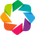

:Scatter   [pBOLD]   (TSNR (Full Brain),Max. Motion (enorm),Max. Motion (dot size),Subject,Session)

In [27]:
hv.extension('bokeh')
cbar_min = df['Max. Motion (enorm)'].quantile(0.05)
cbar_max = df['Max. Motion (enorm)'].quantile(0.99)

df.hvplot.scatter(y='TSNR (Full Brain)',x='pBOLD', hover_cols=['Subject','Session'],aspect='square', s='Max. Motion (dot size)',c='Max. Motion (enorm)', cmap='cividis', fontscale=1.5, frame_width=400).opts(clim=(cbar_min,cbar_max),colorbar_opts={'title':'Max. Motion (mm):'}) 

In [37]:
panel_info = {'b':{'title':"## (b) Low pBOLD, Medium TSNR", 
                   'scan':('sub-109','ses-2'),
                   'grid_top_y':1,
                   'grid_top_x':4,
                   'instacorr_map_nii':'instacorr_map_51s_16r_48p.nii',
                   'instacorr_coords':(16,-48,51),
                   'instacorr_map_png':'./figures/pBOLD_Figure05_b_ICmap.png'},
             'c':{'title':"## (c) Low pBOLD, High TSNR",
                  'scan':('sub-113','ses-1'),
                  'grid_top_y':5,
                  'grid_top_x':4,
                  'instacorr_map_nii':'instacorr_map_05s_25r_27p.nii',
                  'instacorr_coords':(25,-27,5),
                  'instacorr_map_png':'./figures/pBOLD_Figure05_c_ICmap.png'},
             'd':{'title':"## (d) Medium pBOLD, High TSNR",
                  'scan':('sub-191','ses-1'),
                  'grid_top_y':9,
                  'grid_top_x':4,
                  'instacorr_map_nii':'instacorr_map_06i_66a_05r.nii',
                  'instacorr_coords':(-6,66,-5),
                  'instacorr_map_png':'./figures/pBOLD_Figure05_d_ICmap.png'},
             'e':{'title':"## (e) Low TSNR, High pBOLD, High Motion (I)",
                  'scan':('sub-158','ses-1'),
                  'grid_top_y':1,
                  'grid_top_x':8,
                  'instacorr_map_nii':'instacorr_map_11s_01l_59p.nii',
                  'instacorr_coords':(-1,-56,13),
                  'instacorr_map_png':'./figures/pBOLD_Figure05_e_ICmap.png'},
             'f':{'title':"## (f) Low TSNR, High pBOLD, High Motion (II)",
                  'scan':('sub-158','ses-2'),
                  'grid_top_y':5,
                  'grid_top_x':8,
                  'instacorr_map_nii':'instacorr_map_07s_01l_46p.nii',
                  'instacorr_coords':(-1,-56,13),
                  'instacorr_map_png':'./figures/pBOLD_Figure05_f_ICmap.png'},
             'g':{'title':"## (g) Low TSNR, High pBOLD, High Motion (III)",
                  'scan':('sub-177','ses-1'),
                  'grid_top_y':9,
                  'grid_top_x':8,
                  'instacorr_map_nii':'instacorr_map_13s_01l_56p.nii',
                  'instacorr_coords':(-1,-56,13),
                  'instacorr_map_png':'./figures/pBOLD_Figure05_g_ICmap.png'}
}

# Panel a

Generate the static scatter panel (a): add marginal distributions, motion colorbar, good/bad regions, scan annotations, and export as PNG.


In [53]:
# Set seaborn theme
sns.set(style="white", context="notebook")

# Compute quantile limits for color normalization
vmin = df["Max. Motion (enorm)"].quantile(0.05)
vmax = df["Max. Motion (enorm)"].quantile(0.99)

# Create JointGrid
g = sns.JointGrid(data=df, x="pBOLD", y="TSNR (Full Brain)", space=0, height=8)

# Scatter plot with color and size
df           = df[["pBOLD", "TSNR (Full Brain)", "Max. Motion (dot size)", "Max. Motion (enorm)"]].dropna()
pBOLD_MAD    = calculate_mean_deviation(df["pBOLD"].values)
pBOLD_MEDIAN = df["pBOLD"].median()
TSNR_MAD     = calculate_mean_deviation(df["TSNR (Full Brain)"].values)
TSNR_MEDIAN  = df["TSNR (Full Brain)"].median()

sc = g.ax_joint.scatter(
    data=df,
    x="pBOLD",
    y="TSNR (Full Brain)",
    s=df['Max. Motion (dot size)'],
    c=df["Max. Motion (enorm)"],
    cmap="cividis",
    vmin=vmin, vmax=vmax,
    alpha=0.8,
    edgecolor="k",
    linewidth=0.3
)

# Create new axes above the top marginal histogram
pos_joint = g.ax_joint.get_position()
pos_marg_x = g.ax_marg_x.get_position()
pos_marg_y = g.ax_marg_y.get_position()

# Create color bar axis
cbar_ax = g.figure.add_axes([pos_joint.x0, pos_marg_x.y1 + 0.05, pos_joint.width, 0.02])  # [left, bottom, width, height]

# Add horizontal colorbar
cbar = plt.colorbar(sc, cax=cbar_ax, orientation='horizontal')

# Move label and ticks to the top
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.tick_top()
cbar.set_label("Max. Motion (mm)", rotation=0, labelpad=5)

# Top and right marginal plots
sns.histplot(x=df["pBOLD"], ax=g.ax_marg_x, kde=True, color="#72B6A1", edgecolor="black", bins=50)
g.ax_marg_x.axvline(pBOLD_MEDIAN, color="green", linewidth=3, linestyle='--', label='Median')
g.ax_marg_x.axvspan(pBOLD_MEDIAN-2.5*pBOLD_MAD,pBOLD_MEDIAN+2.5*pBOLD_MAD,alpha=0.3,color='lightgreen')

sns.histplot(y=df["TSNR (Full Brain)"], ax=g.ax_marg_y, kde=True, color="#72B6A1", edgecolor="black", bins=50)
g.ax_marg_y.axhline(TSNR_MEDIAN, color='green', linewidth=3, linestyle='--', label='Median')
g.ax_marg_y.axhspan(TSNR_MEDIAN-2.5*TSNR_MAD,TSNR_MEDIAN+2.5*TSNR_MAD,alpha=0.3,color='lightgreen')

# Add Good region
# Define rectangle coordinates
x0 = pBOLD_MEDIAN - 2.5 * pBOLD_MAD
y0 = TSNR_MEDIAN - 2.5 * TSNR_MAD
width  = 5 * pBOLD_MAD   # span from -2 to +2
height = 5 * TSNR_MAD

# Add rectangle to the joint scatterplot
rect_good = patches.Rectangle(
    (x0, y0), width, height,
    linewidth=1.5,
    edgecolor="none",
    facecolor="lightgreen",
    alpha=0.2
)
# Add Bad region
# Define rectangle coordinates
x0 = df['pBOLD'].min()*0.95
y0 = df['TSNR (Full Brain)'].min()*0.95
width  = (pBOLD_MEDIAN - 2.5 * pBOLD_MAD) - x0
height = (TSNR_MEDIAN - 2.5 * TSNR_MAD) - y0

# Add rectangle to the joint scatterplot
rect_bad = patches.Rectangle(
    (x0, y0), width, height,
    linewidth=1.5,
    edgecolor="none",
    facecolor="red",
    alpha=0.2
)

g.ax_joint.add_patch(rect_good)
g.ax_joint.add_patch(rect_bad)

# Axis labels
g.set_axis_labels("$p_{BOLD}$", "TSNR (Full Brain)")

def add_callout(ax, text, xy, xytext, text_color):
    ax.annotate(
        text,
        xy=xy,                 # arrow tip (data coords)
        xytext=xytext,         # text location (data coords)
        fontsize=8,           # hard-coded
        color=text_color,       # hard-coded
        fontweight="light",
        ha="center",
        va="center",
        zorder=20,
        arrowprops=dict(
            arrowstyle="-|>",
            color=text_color,
            lw=1.0,
            mutation_scale=18,
        ),
    )

# Example usage
for panel_idx in panel_info.keys():
    sbj,ses = panel_info[panel_idx]['scan']
    x_coord = df.loc[(sbj,ses),'pBOLD']
    y_coord = df.loc[(sbj,ses),'TSNR (Full Brain)']
    xytext  = '('+panel_idx+')' #(panel_info[panel_idx]['title']).replace('##','')
    if '(b)' in xytext or '(c)' in xytext or 'd' in xytext:
        y_offset = 20
        x_offset = 0
        if 'c' in xytext:
            y_offset = 15
        text_color = '#720072'
    else:
        y_offset = -12
        if 'f' in xytext:
            y_offset = -16
        xoffset = -.2
        text_color =  '#ff8c00'
    add_callout( g.ax_joint, text=xytext, xy=(x_coord,y_coord), xytext=(x_coord+x_offset,y_coord+y_offset), text_color=text_color)

# Improve layout
plt.tight_layout()

# Save to disk
# After all plotting code (and before/without plt.show())
out_png = "./figures/pBOLD_Figure05_a.png"

g.figure.savefig( out_png, dpi=300, bbox_inches="tight",   # critical: captures cbar outside default figure bounds
    pad_inches=0.05)

print(f"Saved: {out_png}")

/tmp/ipykernel_3153400/1444466570.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: ./figures/pBOLD_Figure05_a.png


# Create PNG for Instacorr Brain Maps

For each selected scan, render the Instacorr seed map on anatomy and save a PNG used in the final figure.


In [54]:
hv.extension('matplotlib')
ICmaps_dict = {}
for panel_idx in tqdm(panel_info.keys()):
    (sbj,ses)          = panel_info[panel_idx]['scan']
    instacorr_map_path = osp.join(PRCS_DATA_DIR,sbj,f'D03_Preproc_{ses}_NORDIC-off',panel_info[panel_idx]['instacorr_map_nii'])
    anat_path          = osp.join(PRCS_DATA_DIR,sbj,f'D03_Preproc_{ses}_NORDIC-off',f'anat_final.{sbj}.nii')
    this_map           = show_map_of_interest(anat_path,instacorr_map_path,
                                              panel_info[panel_idx]['instacorr_coords'],
                                              panel_info[panel_idx]['instacorr_map_png'], 
                                              cmap='RdBu_r', show_cbar=False)
    ICmaps_dict[panel_idx] = panel_info[panel_idx]['instacorr_map_png']

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

  0%|          | 0/6 [00:00<?, ?it/s]

++ Saving image to disk: ./figures/pBOLD_Figure05_b_ICmap.png
++ Saving image to disk: ./figures/pBOLD_Figure05_c_ICmap.png
++ Saving image to disk: ./figures/pBOLD_Figure05_d_ICmap.png
++ Saving image to disk: ./figures/pBOLD_Figure05_e_ICmap.png
++ Saving image to disk: ./figures/pBOLD_Figure05_f_ICmap.png
++ Saving image to disk: ./figures/pBOLD_Figure05_g_ICmap.png


# Create PNG for FC matrices

Create FC matrix visualizations for each selected scan using atlas/network styling and store them for layout composition.


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
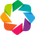

  0%|          | 0/6 [00:00<?, ?it/s]

In [ ]:
hv.extension('bokeh')
FCmats_dict = {}
for panel_idx in tqdm(panel_info.keys()):
    (sbj,ses)    = panel_info[panel_idx]['scan']
    this_fc      = data_fc[sbj,ses,'ALL_Basic','off','e02|e02','corr']
    this_fc_plot = hvplot_fc(this_fc,
                             major_label_overrides='regular_grid', 
                             net_cmap=power264_nw_cmap,
                             cmap='RdBu_r', by='Network', add_labels=False, 
                             colorbar_position='left', clim=(-.8,.8), cbar_title='',
                             cbar_title_fontsize=14,ticks_font_size=14, remove_colorbar=True).opts(default_tools=["pan"]).opts(toolbar=None)
    FCmats_dict[panel_idx] = this_fc_plot

# Respiratory Traces

Build compact respiratory trace plots for each selected scan to include under each panel row.


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
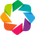

  0%|          | 0/6 [00:00<?, ?it/s]

In [56]:
hv.extension('bokeh')
resp_dict = {}
# Define hook function to remove border
def remove_frame(plot, element):
    plot.state.outline_line_color = None
    # Optional: remove background/border fill
for panel_idx in tqdm(panel_info.keys()):
    this_trace = physio_traces[panel_info[panel_idx]['scan'][0],panel_info[panel_idx]['scan'][1],'resp']
    this_ylim  = (this_trace.min().values[0],this_trace.max().values[0])
    resp_dict[panel_idx] = this_trace.hvplot(c='k',width=800, height=150, line_width=1, ylim=this_ylim).opts(shared_axes=False, toolbar=None, xaxis=None, yaxis=None, hooks=[remove_frame])

# Creating Final Figure Layout

Assemble panel (a), banners, Instacorr maps, FC matrices, and respiratory traces into one Panel layout and export HTML.


In [57]:
bad_pBOLD_banner = pn.pane.HTML(
    """
    <div style="
        width:100%;
        background:#720072;
        color:#fff;
        font-weight:700;
        text-align:center;
        padding:10px 12px;
        box-sizing:border-box;
        font-size:24px;
        width:700px;
    ">
      Scans deemed problematic only by pBOLD
    </div>
    """)
bad_TSNR_banner = pn.pane.HTML(
    """
    <div style="
        width:100%;
        background:#ff8c00;
        color:#fff;
        font-weight:700;
        text-align:center;
        padding:10px 12px;
        box-sizing:border-box;
        font-size:24px;
        width:700px;
    ">
      Scans deemed problematic only by TSNR
    </div>
    """)

In [58]:
row_banners = pn.Row(bad_pBOLD_banner,bad_TSNR_banner)
row_be = pn.Row(pn.Column(pn.pane.Markdown(panel_info['b']['title'], height=20),
          pn.Row(pn.pane.PNG(ICmaps_dict['b'],height=200),
          pn.pane.HoloViews(FCmats_dict['b'], height=200, width=200)),
          pn.pane.HoloViews(resp_dict['b'], height=100, width=700)),
       pn.Column(pn.pane.Markdown(panel_info['e']['title'], height=20),
          pn.Row(pn.pane.PNG(ICmaps_dict['e'],height=200),
          pn.pane.HoloViews(FCmats_dict['e'], height=200, width=200)),
          pn.pane.HoloViews(resp_dict['e'], height=100, width=700)))

row_cf = pn.Row(pn.Column(pn.pane.Markdown(panel_info['c']['title'], height=20),
          pn.Row(pn.pane.PNG(ICmaps_dict['c'],height=200),
          pn.pane.HoloViews(FCmats_dict['c'], height=200, width=200)),
          pn.pane.HoloViews(resp_dict['c'], height=100, width=700)),
       pn.Column(pn.pane.Markdown(panel_info['f']['title'], height=20),
          pn.Row(pn.pane.PNG(ICmaps_dict['f'],height=200),
          pn.pane.HoloViews(FCmats_dict['f'], height=200, width=200)),
          pn.pane.HoloViews(resp_dict['f'], height=100, width=700)))

row_dg = pn.Row(pn.Column(pn.pane.Markdown(panel_info['d']['title'], height=20),
          pn.Row(pn.pane.PNG(ICmaps_dict['d'],height=200),
          pn.pane.HoloViews(FCmats_dict['d'], height=200, width=200)),
          pn.pane.HoloViews(resp_dict['d'], height=100, width=700)),
       pn.Column(pn.pane.Markdown(panel_info['g']['title'], height=20),
          pn.Row(pn.pane.PNG(ICmaps_dict['g'],height=200),
          pn.pane.HoloViews(FCmats_dict['g'], height=200, width=200)),
          pn.pane.HoloViews(resp_dict['g'], height=100, width=700)))


In [60]:
pn.Row(pn.pane.Markdown('## (a)',width=10),
    pn.pane.PNG('./figures/pBOLD_Figure05_a.png', width=1000, height=1000),
    pn.Column(row_banners, row_be,row_cf, row_dg)).save('./figures/pBOLD_Figure05.html')

Here is a static version of the figure generated above.

![Figure05](figures/pBOLD_Figure05.png)
